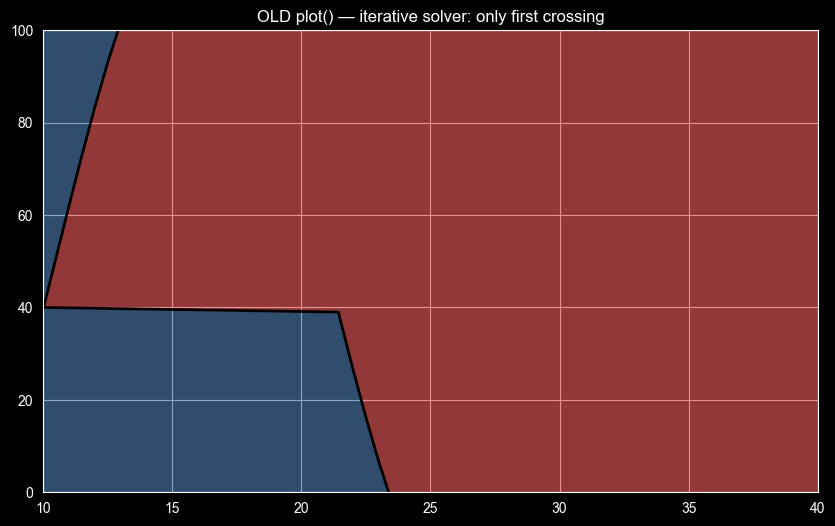

TypeError: can't multiply sequence by non-int of type 'float'

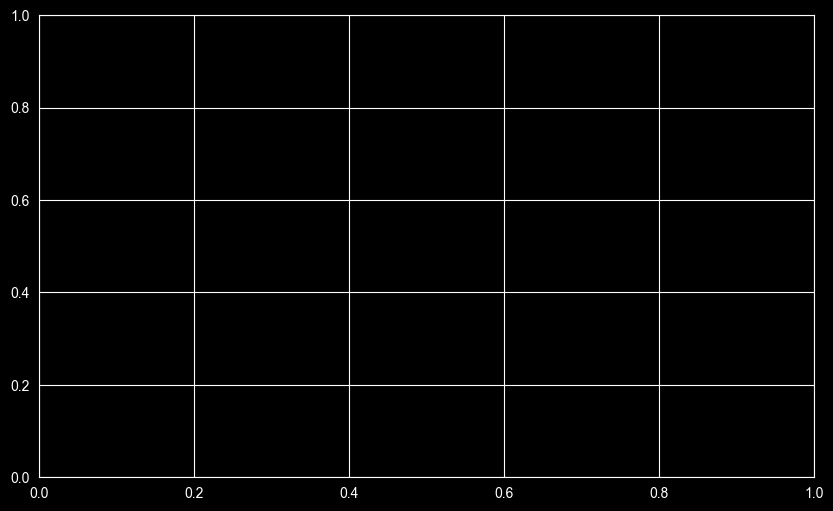

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from range_scene_old import RangeScene as RangeSceneOld
import math


'''def wavy_comfort_model(tdb, rh, **kwargs):
    tdb = np.asarray(tdb)
    rh = np.asarray(rh)
    return {"output": np.sin(tdb * 0.3) * 3 + (rh - 50) * 0.04}'''


def wavy_comfort_model(tdb: float, rh: float, **kwargs) -> dict:
    return {"output": math.sin(tdb * 0.3) * 3 + (rh - 50) * 0.04}


scene = RangeSceneOld(wavy_comfort_model)
scene.x(tdb=(10, 40)).y(rh=(0, 100)).parameters()

fig, ax = plt.subplots(figsize=(10, 6))
scene.plot(
    output="output",
    levels=[0.0],
    colors=["#4c78a8", "#e15759"],
    x_step=0.5,
    y_step=1.0,
    ax=ax,
    show_lines=True,
    line_kws={"color": "black", "linewidth": 2},
)
ax.set_title("OLD plot() — iterative solver: only first crossing")
plt.show()

scene = RangeSceneOld(wavy_comfort_model)
scene.x(tdb=(10, 40)).y(rh=(0, 100)).parameters()

fig, ax = plt.subplots(figsize=(10, 6))
scene.plot_contour(
    output="output",
    levels=[0.0],
    colors=["#4c78a8", "#e15759"],
    grid_resolution=150,
    ax=ax,
    show_lines=True,
    line_kws={"color": "black", "linewidth": 2},
)
ax.set_title("OLD plot_contour() — marching squares: all crossings correct")
plt.show()

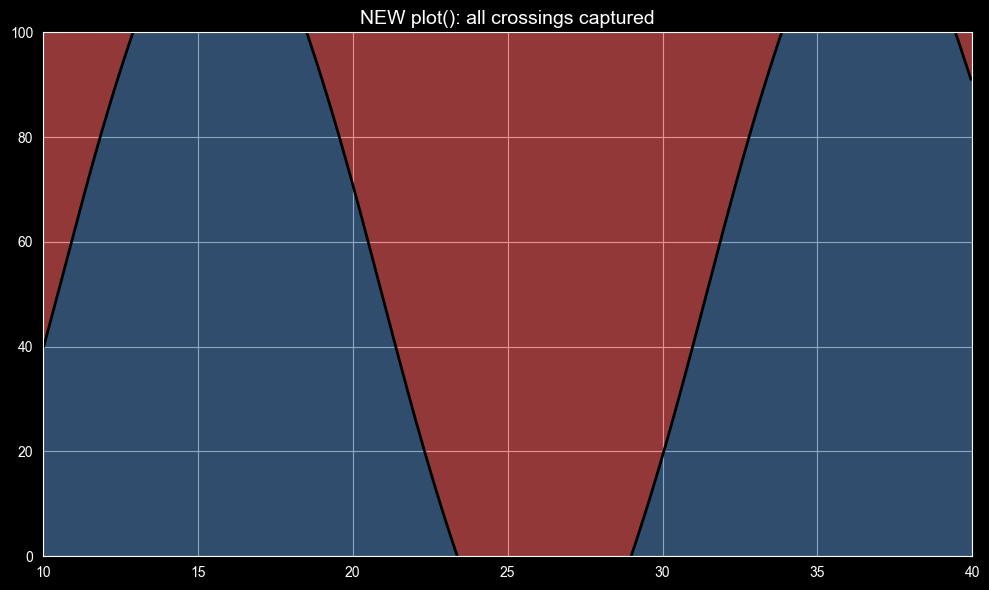

In [23]:
from range_scene import RangeScene

scene = RangeScene(wavy_comfort_model)
scene.x(tdb=(10, 40)).y(rh=(0, 100)).parameters()

fig, ax = plt.subplots(figsize=(10, 6))
result = scene.plot(
    output="output",
    levels=[0.0],
    colors=["#4c78a8", "#e15759"],
    x_step=0.5,
    y_step=1.0,
    ax=ax,
    show_lines=True,
    line_kws={"color": "black", "linewidth": 2},
)
ax.set_title("NEW plot(): all crossings captured", fontsize=14)
plt.tight_layout()
plt.show()

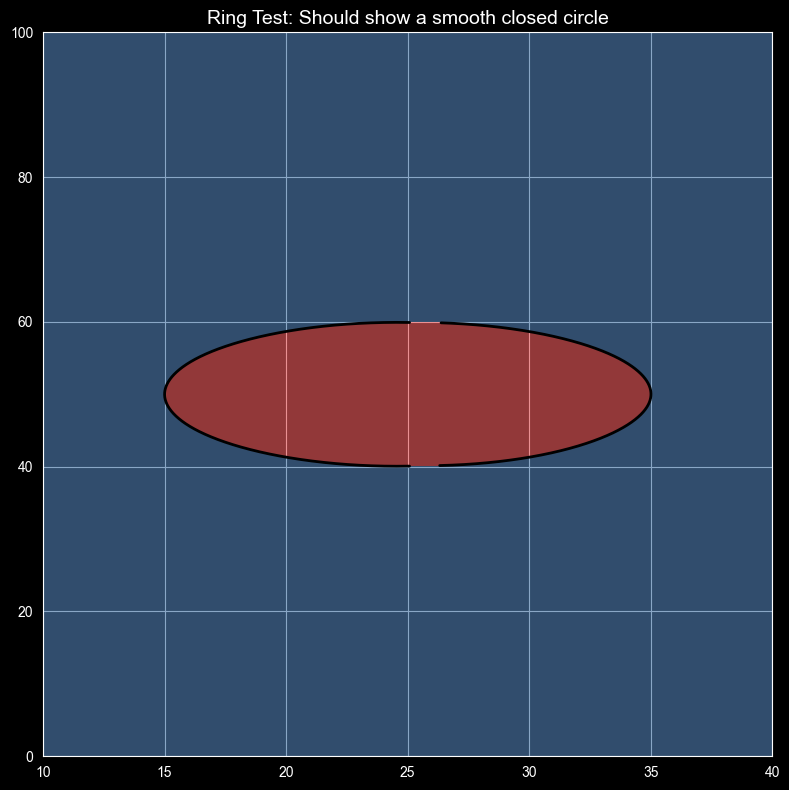

In [21]:
import math

import matplotlib.pyplot as plt
from range_scene import RangeScene


def ring_comfort_model(tdb: float, rh: float, **kwargs) -> dict:
    dist = math.sqrt((tdb - 25) ** 2 + (rh - 50) ** 2)
    return {"output": 10 - dist}


scene = RangeScene(ring_comfort_model)
scene.x(tdb=(10, 40)).y(rh=(0, 100)).parameters()

fig, ax = plt.subplots(figsize=(8, 8))

result = scene.plot(
    output="output",
    levels=[0.0],
    colors=["#4c78a8", "#e15759"],
    x_step=0.5,
    y_step=0.1,
    ax=ax,
    show_lines=True,
    smooth=True,
    line_kws={"color": "black", "linewidth": 2},
)

ax.set_title("Ring Test: Should show a smooth closed circle", fontsize=14)
plt.tight_layout()
plt.show()

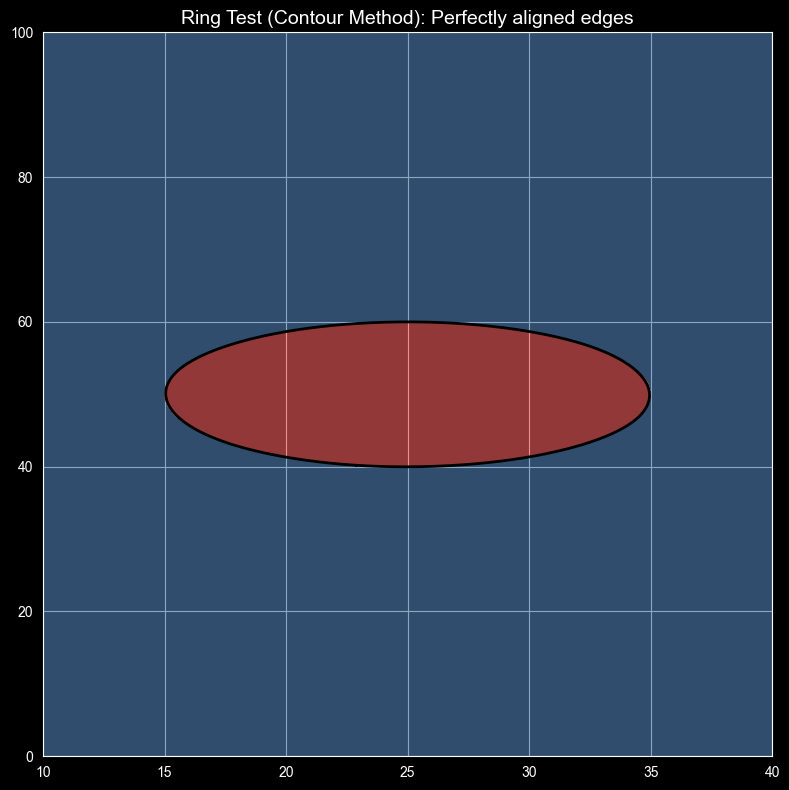

In [13]:
import matplotlib.pyplot as plt
from range_scene import RangeScene


def ring_comfort_model(tdb: float, rh: float, **kwargs) -> dict:
    dist = np.sqrt((tdb - 25) ** 2 + (rh - 50) ** 2)
    return {"output": 10 - dist}


scene = RangeScene(ring_comfort_model)
scene.x(tdb=(10, 40)).y(rh=(0, 100)).parameters()

fig, ax = plt.subplots(figsize=(8, 8))

grid = scene.compute_contour(output="output", grid_resolution=150)

result = scene.render_contour(
    grid,
    levels=[0.0],
    colors=["#4c78a8", "#e15759"],
    ax=ax,
    show_lines=True,
    line_kws={"color": "black", "linewidth": 2},
)

ax.set_title("Ring Test (Contour Method): Perfectly aligned edges", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
import matplotlib.pyplot as plt
from range_scene import RangeScene
from range_scene_old import RangeScene as RangeSceneOld

from pythermalcomfort.models import pmv_ppd_iso

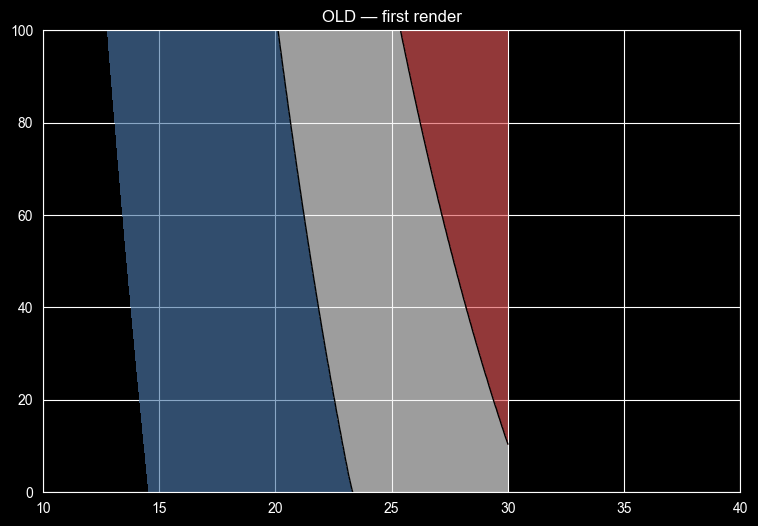

In [25]:
scene_old = RangeSceneOld(pmv_ppd_iso)
scene_old.x(tdb=(10, 40)).y(rh=(0, 100)).parameters(tr=25, vr=0.1, met=1.2, clo=0.5)

result = scene_old.plot_contour(
    output="pmv",
    levels=[-0.5, 0.5],
    grid_resolution=4000,
    colors=["#4c78a8", "#f2f2f2", "#e15759"],
)
plt.title("OLD — first render")
plt.show()

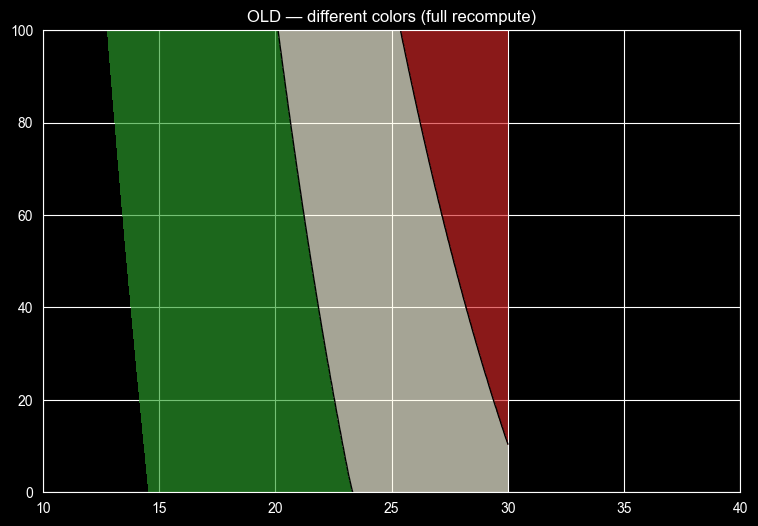

In [26]:
result = scene_old.plot_contour(
    output="pmv",
    levels=[-0.5, 0.5],
    grid_resolution=4000,
    colors=["#2ca02c", "#fffde7", "#d62728"],
)
plt.title("OLD — different colors (full recompute)")
plt.show()

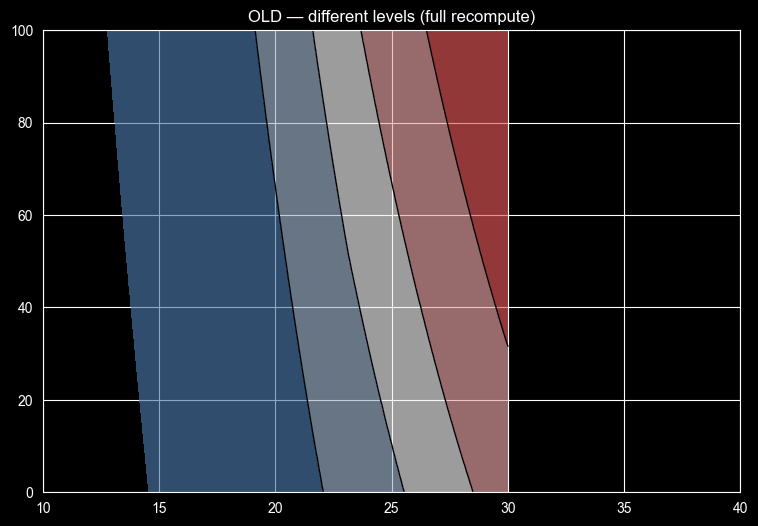

In [27]:
result = scene_old.plot_contour(
    output="pmv",
    levels=[-0.7, -0.2, 0.2, 0.7],
    grid_resolution=4000,
)
plt.title("OLD — different levels (full recompute)")
plt.show()

In [28]:
scene_new = RangeScene(pmv_ppd_iso)
scene_new.x(tdb=(10, 40)).y(rh=(0, 100)).parameters(tr=25, vr=0.1, met=1.2, clo=0.5)

grid = scene_new.compute_contour(output="pmv", grid_resolution=4000)

C:\Users\87872\AppData\Local\Temp\ipykernel_24416\3549194175.py:4: UserWarning: grid_resolution=4,000 creates 16,000,000 grid points (~0.4 GB). Resolutions above 2,000 rarely improve visual quality. Consider using smooth=True with a moderate resolution instead.
  grid = scene_new.compute_contour(output="pmv", grid_resolution=4000)


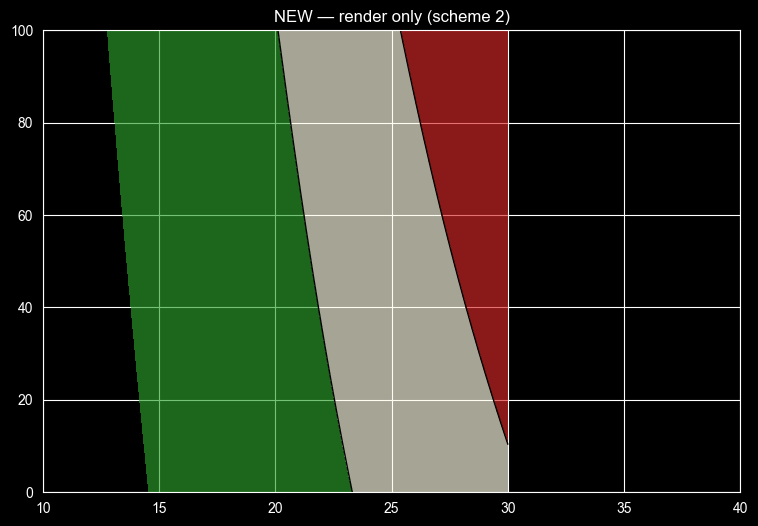

In [29]:
result = scene_new.render_contour(
    grid,
    levels=[-0.5, 0.5],
    colors=["#2ca02c", "#fffde7", "#d62728"],
)
plt.title("NEW — render only (scheme 2)")
plt.show()

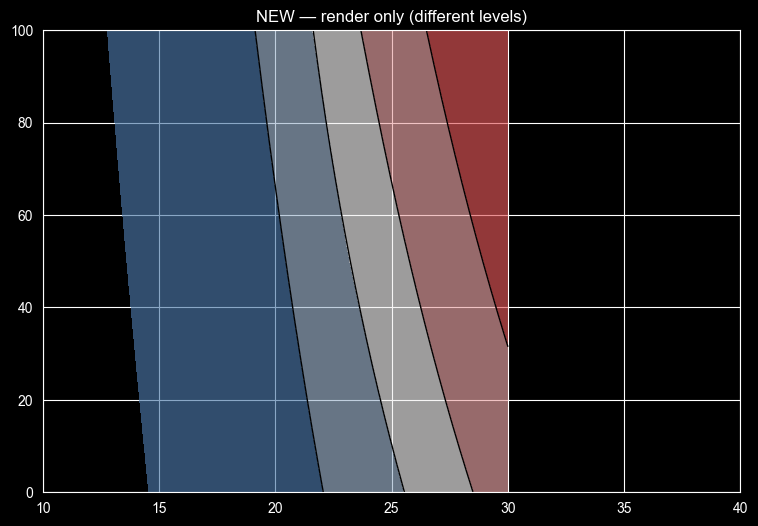

In [30]:
result = scene_new.render_contour(
    grid,
    levels=[-0.7, -0.2, 0.2, 0.7],
)
plt.title("NEW — render only (different levels)")
plt.show()